# Module 6 — Day 1: Decision Trees
## PHY 657, Spring 2026

---

### Where we are

We now have two very different classifiers in our toolkit:

- **Logistic regression** (Module 4): draws a hyperplane in feature space. Simple, fast, interpretable — but limited to linear boundaries.
- **Neural networks** (Module 5): learn non-linear boundaries by stacking layers. Powerful — but opaque, slow to train, and require careful tuning.

Today we introduce a third approach that is fundamentally different from both: **decision trees**. There are no weights, no gradients, no activation functions. A decision tree classifies data by asking a sequence of yes/no questions — like a flowchart. The result is the most interpretable classifier we will encounter: you can literally read the decision logic out loud.

The catch: single trees overfit badly. This will motivate ensemble methods (Days 2–3), which turn fragile trees into one of the most powerful and practical tools in applied machine learning.

### Plan
1. The decision tree idea: recursive binary splits
2. How to choose splits: Gini impurity and information gain
3. Visualizing tree decisions
4. Overfitting and regularization (max_depth, pruning)
5. Application to the Ising model — comparison with logistic regression and neural networks

---
## Part 0: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})
RNG = np.random.default_rng(42)

---
## Part 1: The Decision Tree Idea

### A different way to classify

Logistic regression and neural networks both compute a **function** of the input: a weighted sum, passed through activations, producing a probability. Decision trees do something completely different: they ask a **sequence of questions** about the features.

Imagine you are sorting particles by hand. You might ask:
- Is the energy above 10 keV? If yes, go right; if no, go left.
- On the left branch: is the rise time above 20 µs? If yes → background; if no → signal.
- On the right branch: is the baseline stable? If yes → signal; if no → background.

Each question splits the data into two groups based on a **single feature** and a **threshold**. The tree keeps splitting until it reaches a final classification.

### What a split looks like geometrically

Each split is an **axis-aligned cut**: a vertical or horizontal line in feature space. This is very different from logistic regression (which draws an arbitrary hyperplane) or a neural network (which draws curved boundaries).

Let us build a simple 2D example to see this.

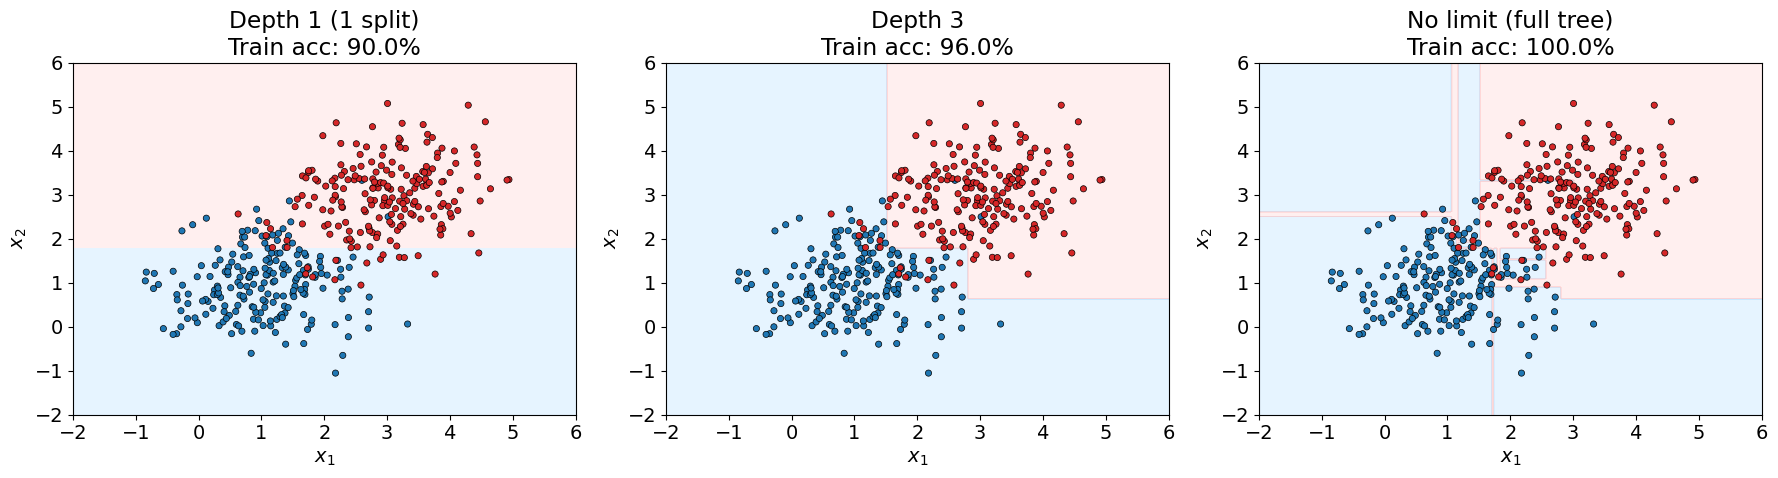

In [2]:
# Generate a simple 2D dataset: two Gaussian blobs
n = 200
X_blob = np.vstack([
    RNG.normal(loc=[1, 1], scale=0.8, size=(n, 2)),
    RNG.normal(loc=[3, 3], scale=0.8, size=(n, 2)),
])
y_blob = np.array([0]*n + [1]*n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap_bg = ListedColormap(['#AEDDFF', '#FFCCCC'])
cmap_pts = ListedColormap(['tab:blue', 'tab:red'])

for ax, depth, title in zip(axes, [1, 3, None], 
                              ['Depth 1 (1 split)', 'Depth 3', 'No limit (full tree)']):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0)
    tree.fit(X_blob, y_blob)
    
    # Decision boundary
    xx, yy = np.meshgrid(np.linspace(-2, 6, 300), np.linspace(-2, 6, 300))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=cmap_pts, 
              edgecolors='k', s=20, linewidths=0.5)
    acc = tree.score(X_blob, y_blob)
    ax.set_title(f'{title}\nTrain acc: {acc:.1%}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

Notice the key features of decision tree boundaries:

- Every boundary is **axis-aligned** — horizontal or vertical cuts only
- Deeper trees make more cuts, creating a staircase approximation to the true boundary
- The full tree can achieve 100% training accuracy by carving out tiny boxes around every point — this is overfitting

### Reading the tree

One of the great strengths of decision trees: you can read the entire decision logic. Let us look at the depth-3 tree.

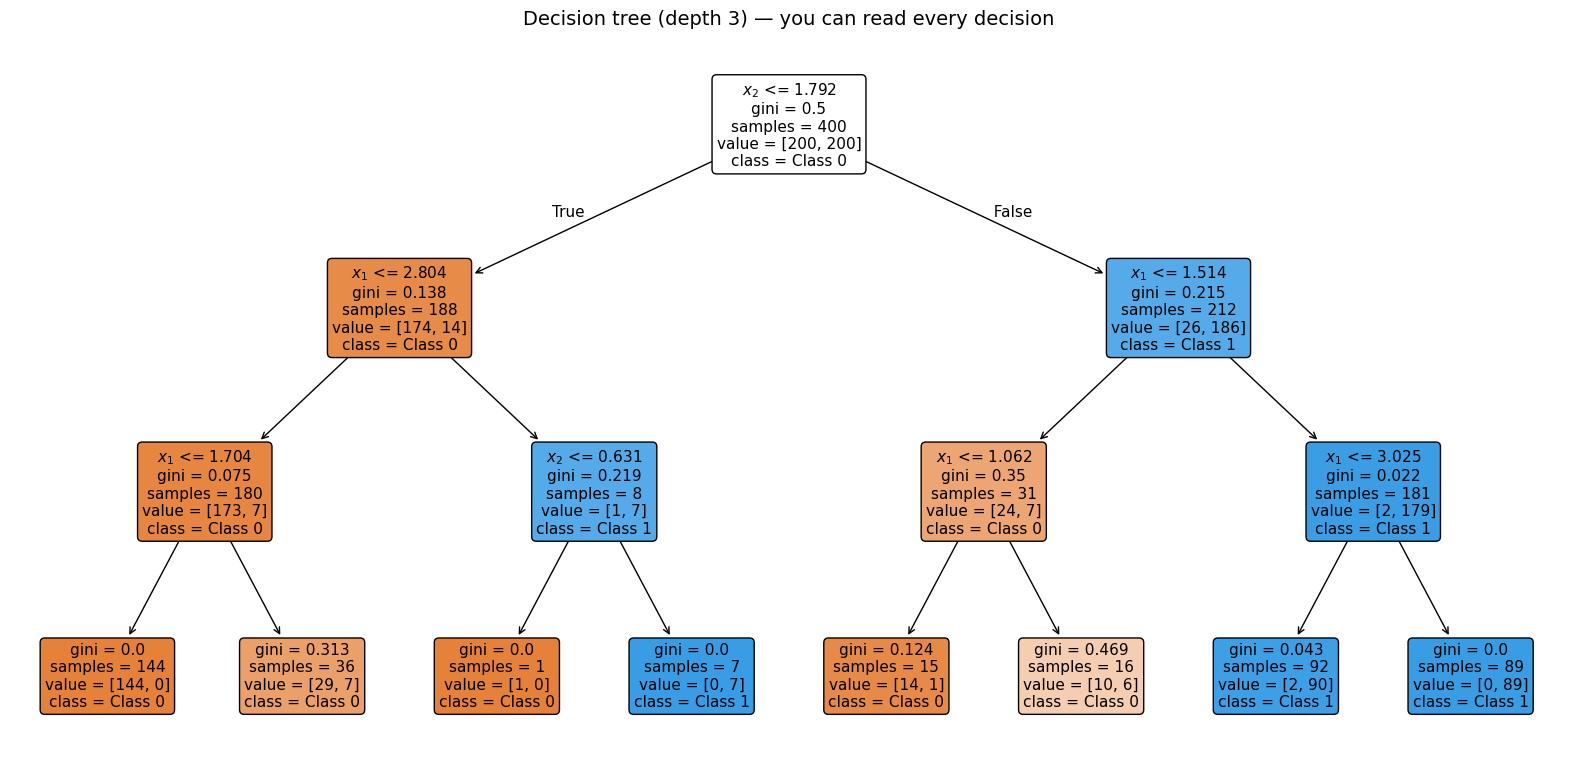

In [3]:
tree_d3 = DecisionTreeClassifier(max_depth=3, random_state=0)
tree_d3.fit(X_blob, y_blob)

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree_d3, feature_names=['$x_1$', '$x_2$'], class_names=['Class 0', 'Class 1'],
          filled=True, rounded=True, ax=ax, fontsize=11)
ax.set_title('Decision tree (depth 3) — you can read every decision', fontsize=14)
plt.tight_layout()
plt.show()

Each node shows:
- The **split rule** (e.g., $x_1 \leq 2.13$)
- The **Gini impurity** (a measure of how mixed the classes are — more on this next)
- The **number of samples** that reach this node
- The **class distribution** at this node

To classify a new point, start at the root and follow the branches. This is exactly the flowchart logic we described earlier.

Try doing this with a neural network — you cannot. This is why decision trees are valuable even when they are less accurate: **you can understand exactly what they are doing.**

---
## Part 2: How Trees Choose Splits

The tree needs to decide, at each node: which feature to split on, and at what threshold? The algorithm tries every possible feature and every possible threshold, and picks the one that best separates the classes.

But what does "best separates" mean? We need a way to measure how mixed (impure) a set of labels is.

### Gini impurity

For a node with $N$ samples, let $p_k$ be the fraction of samples belonging to class $k$. The **Gini impurity** is:

$G = 1 - \sum_{k} p_k^2$

For binary classification with class-1 fraction $p$, this becomes $G = 1 - p^2 - (1-p)^2$.

- If a node is **pure** (all one class): $G = 1 - 1^2 = 0$
- If a node is maximally mixed (50/50 for binary): $G = 1 - 0.25 - 0.25 = 0.5$

The tree picks the split that produces the **purest subsets** — i.e., the lowest weighted Gini after splitting.

### Information gain (entropy criterion)

An alternative measure uses Shannon entropy:

$$H = -\sum_{k} p_k \log_2 p_k$$

The **information gain** of a split is the decrease in entropy. This is directly connected to the information theory you may have encountered in statistical mechanics — entropy measures uncertainty, and a good split reduces uncertainty about the class.

In practice, Gini and entropy usually give very similar trees. Scikit-learn uses Gini by default.

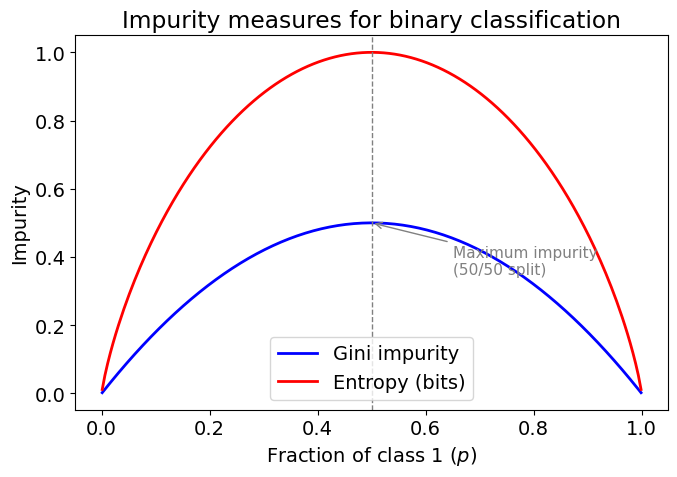

In [4]:
# Visualize Gini and entropy as functions of p
p = np.linspace(0.001, 0.999, 200)
gini = 1 - p**2 - (1 - p)**2  # = 2p(1-p) for binary
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(p, gini, 'b-', lw=2, label='Gini impurity')
ax.plot(p, entropy, 'r-', lw=2, label='Entropy (bits)')
ax.set_xlabel('Fraction of class 1 ($p$)')
ax.set_ylabel('Impurity')
ax.set_title('Impurity measures for binary classification')
ax.axvline(0.5, color='gray', ls='--', lw=1)
ax.legend()
ax.annotate('Maximum impurity\n(50/50 split)', xy=(0.5, 0.5), xytext=(0.65, 0.35),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11, color='gray')
plt.tight_layout()
plt.show()

### Watching the tree split step by step

Let us make this concrete. We will create a dataset and show what the tree considers at the first split.

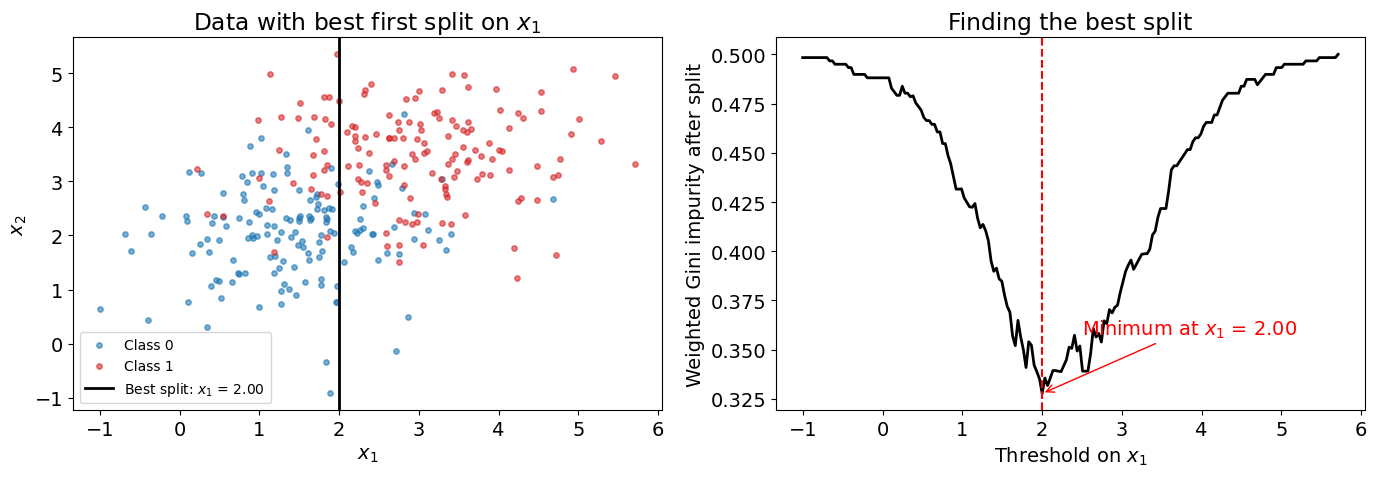

In [5]:
# A slightly harder 2D problem: overlapping classes
n = 150
X_demo = np.vstack([
    RNG.normal([1.5, 2.0], [1.0, 0.8], (n, 2)),
    RNG.normal([3.0, 3.5], [1.0, 0.8], (n, 2)),
])
y_demo = np.array([0]*n + [1]*n)

def gini_impurity(y):
    if len(y) == 0:
        return 0
    p = np.mean(y)
    return 2 * p * (1 - p)

def weighted_gini(y_left, y_right):
    n_total = len(y_left) + len(y_right)
    return (len(y_left) * gini_impurity(y_left) + 
            len(y_right) * gini_impurity(y_right)) / n_total

# Scan all thresholds for feature 0
thresholds = np.linspace(X_demo[:, 0].min(), X_demo[:, 0].max(), 200)
gini_scores = []
for t in thresholds:
    left = y_demo[X_demo[:, 0] <= t]
    right = y_demo[X_demo[:, 0] > t]
    gini_scores.append(weighted_gini(left, right))

best_t = thresholds[np.argmin(gini_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_demo[:n, 0], X_demo[:n, 1], c='tab:blue', s=15, alpha=0.6, label='Class 0')
axes[0].scatter(X_demo[n:, 0], X_demo[n:, 1], c='tab:red', s=15, alpha=0.6, label='Class 1')
axes[0].axvline(best_t, color='k', ls='-', lw=2, label=f'Best split: $x_1$ = {best_t:.2f}')
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')
axes[0].set_title('Data with best first split on $x_1$')
axes[0].legend(fontsize=10)

axes[1].plot(thresholds, gini_scores, 'k-', lw=2)
axes[1].axvline(best_t, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Threshold on $x_1$')
axes[1].set_ylabel('Weighted Gini impurity after split')
axes[1].set_title('Finding the best split')
axes[1].annotate(f'Minimum at $x_1$ = {best_t:.2f}', xy=(best_t, min(gini_scores)),
                xytext=(best_t + 0.5, min(gini_scores) + 0.03),
                arrowprops=dict(arrowstyle='->', color='red'), color='red')

plt.tight_layout()
plt.show()

The tree scans all possible thresholds for each feature and picks the one that produces the **purest subsets** — i.e., the lowest weighted Gini $G_{\text{split}}$.

It then repeats this process independently on each resulting subset — recursively, until it reaches a stopping criterion. Each node is its own optimization problem: given the data that arrived at this node, find the single best split.

You will sometimes see this described as picking the split with the *largest decrease* in Gini impurity. This means the decrease from the **parent node to its two subsets within a single split**, not a decrease between successive levels of the tree:

$\Delta G = G(\text{parent}) - G_{\text{split}}$

Since $G(\text{parent})$ is the same for all candidate splits at a given node, minimizing $G_{\text{split}}$ and maximizing $\Delta G$ are the same thing.

The following diagram shows how this works. On the left is a scatter plot of 20 data points with two classes (blue and red). The dashed red line shows the split the tree chose: $x_1 = 2.1$. On the right, the tree structure shows the Gini arithmetic — how the split divides the data and reduces impurity.

<img src="gini-diagram.svg" width="750">

### The full algorithm

```
function BuildTree(data, labels):
    if stopping condition met:
        return LeafNode(majority class)
    
    for each feature j:
        for each threshold t:
            compute weighted Gini of the two subsets from splitting on (j, t)
    
    pick the (j*, t*) with the lowest weighted Gini
    split data into left (feature j* ≤ t*) and right (feature j* > t*)
    
    left_subtree  = BuildTree(left_data,  left_labels)
    right_subtree = BuildTree(right_data, right_labels)
    return Node(feature=j*, threshold=t*, left=left_subtree, right=right_subtree)
```

The stopping conditions can be: maximum depth reached, minimum samples per leaf, node is already pure, etc.

---
## Part 3: Overfitting — Trees Growing Wild

Without a depth limit, a decision tree will keep splitting until every leaf contains a single sample (or all samples in the leaf are from the same class). This is perfect on the training data — and terrible on new data.

This is the same overfitting story from Module 1 (high-degree polynomials) and Module 5 (large neural networks on small data). The common thread: **a model with too many free decisions relative to the amount of data will memorize rather than generalize.**

For a tree, the number of "free decisions" is controlled by the **depth**. A tree of depth $d$ can make at most $2^d$ distinct regions in feature space — analogous to a polynomial of degree $d$ or a neural network with $\sim 2^d$ effective parameters.

Let us watch this happen.

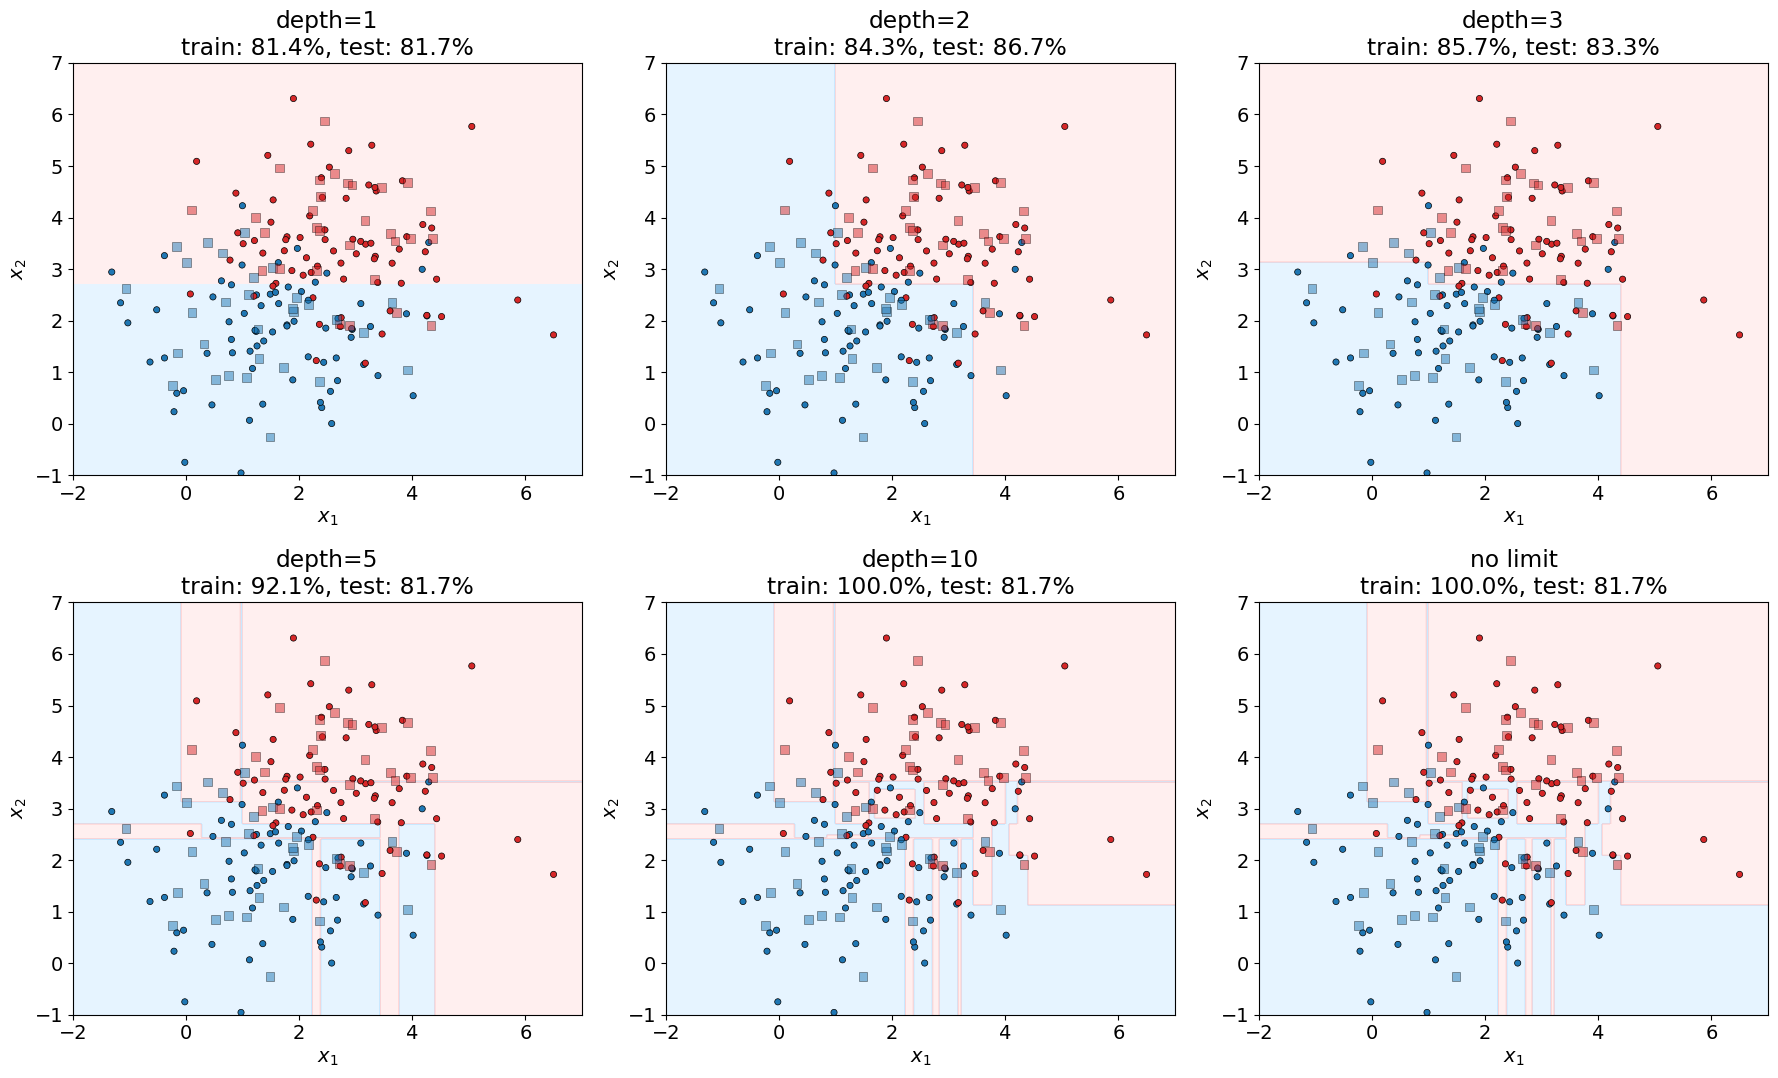

In [6]:
# Create a noisier dataset for the overfitting demo
n = 100
X_over = np.vstack([
    RNG.normal([1.5, 2.0], [1.2, 1.0], (n, 2)),
    RNG.normal([3.0, 3.5], [1.2, 1.0], (n, 2)),
])
y_over = np.array([0]*n + [1]*n)

X_tr_ov, X_te_ov, y_tr_ov, y_te_ov = train_test_split(
    X_over, y_over, test_size=0.3, random_state=0, stratify=y_over
)

depths = [1, 2, 3, 5, 10, None]
train_accs, test_accs = [], []

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for i, d in enumerate(depths):
    tree = DecisionTreeClassifier(max_depth=d, random_state=0)
    tree.fit(X_tr_ov, y_tr_ov)
    
    tr_acc = tree.score(X_tr_ov, y_tr_ov)
    te_acc = tree.score(X_te_ov, y_te_ov)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    
    xx, yy = np.meshgrid(np.linspace(-2, 7, 300), np.linspace(-1, 7, 300))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    axes[i].scatter(X_tr_ov[:, 0], X_tr_ov[:, 1], c=y_tr_ov, cmap=cmap_pts,
                   edgecolors='k', s=20, linewidths=0.5)
    axes[i].scatter(X_te_ov[:, 0], X_te_ov[:, 1], c=y_te_ov, cmap=cmap_pts,
                   edgecolors='k', s=40, linewidths=0.5, marker='s', alpha=0.5)
    label = f'depth={d}' if d is not None else 'no limit'
    axes[i].set_title(f'{label}\ntrain: {tr_acc:.1%}, test: {te_acc:.1%}')
    axes[i].set_xlabel('$x_1$'); axes[i].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

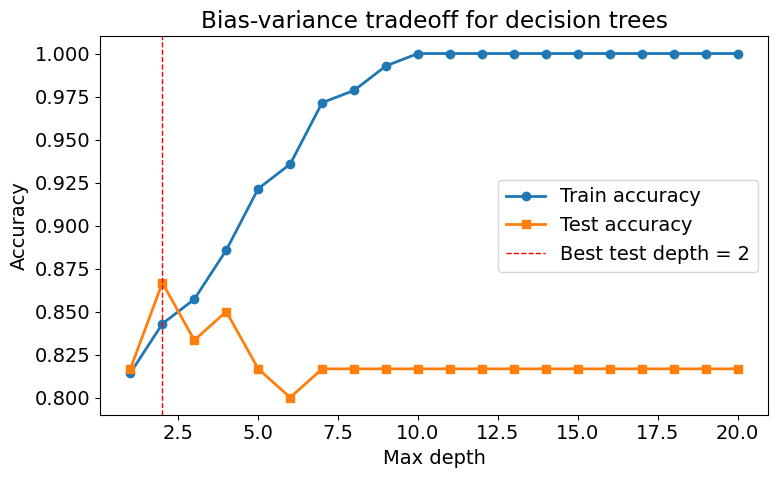

Best test accuracy: 86.7% at depth 2
Unlimited tree test accuracy: 81.7% at depth 20


In [7]:
# Bias-variance tradeoff: accuracy vs depth
depth_range = list(range(1, 21))
tr_curve, te_curve = [], []

for d in depth_range:
    tree = DecisionTreeClassifier(max_depth=d, random_state=0)
    tree.fit(X_tr_ov, y_tr_ov)
    tr_curve.append(tree.score(X_tr_ov, y_tr_ov))
    te_curve.append(tree.score(X_te_ov, y_te_ov))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_range, tr_curve, 'o-', lw=2, label='Train accuracy')
ax.plot(depth_range, te_curve, 's-', lw=2, label='Test accuracy')
ax.set_xlabel('Max depth')
ax.set_ylabel('Accuracy')
ax.set_title('Bias-variance tradeoff for decision trees')
ax.legend()

best_d = depth_range[np.argmax(te_curve)]
ax.axvline(best_d, color='red', ls='--', lw=1, label=f'Best test depth = {best_d}')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Best test accuracy: {max(te_curve):.1%} at depth {best_d}')
print(f'Unlimited tree test accuracy: {te_curve[-1]:.1%} at depth 20')

**The pattern is exactly what we saw before:**
- Shallow trees underfit (high bias): the boundary is too simple to capture the data
- Deep trees overfit (high variance): the boundary memorizes noise in the training data
- There is a sweet spot in between

`max_depth` plays the same role as:
- Polynomial degree in Module 1
- $k$ in KNN (Module 4, but inverted — smaller $k$ = more complex)
- Network size in Module 5

Other regularization knobs for trees:
- `min_samples_split`: require at least $n$ samples to make a split
- `min_samples_leaf`: require at least $n$ samples in each leaf
- `max_leaf_nodes`: limit the total number of leaves

All of these prevent the tree from growing too complex.

---
## Breakout Exercise (~15 min)

**Open the breakout notebook and work with your partner.**

You are given a 2D "moons" dataset (two interleaving half-circles). This is a non-linearly separable problem.

1. Fit a `DecisionTreeClassifier` with `max_depth=2`. Plot the decision boundary and report train/test accuracy.
2. Repeat with `max_depth=10` and `max_depth=None` (unlimited).
3. Use `plot_tree` to visualize the depth-2 tree. How many splits does it make? Can you describe the decision logic in words?
4. Also fit a `LogisticRegression` on the same data. Which does better?

Discuss: In what situations would you prefer the tree over logistic regression, even if it has lower accuracy?

---
## Part 4: Application to the Ising Model

Let us return to our running example from Module 5: classifying Ising model configurations into ordered vs disordered phases.

Recall:
- Logistic regression struggles because the relevant feature ($|M|$) is non-linear
- Neural networks succeed because they can learn non-linear features
- What about decision trees?

In [8]:
def ising_monte_carlo(L, T, n_steps=5000, rng=None):
    if rng is None:
        rng = RNG
    spins = rng.choice([-1, 1], size=(L, L))
    for step in range(n_steps):
        i, j = rng.integers(0, L, size=2)
        neighbors = (
            spins[(i+1) % L, j] + spins[(i-1) % L, j] +
            spins[i, (j+1) % L] + spins[i, (j-1) % L]
        )
        dE = 2 * spins[i, j] * neighbors
        if dE <= 0 or rng.random() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins


def generate_ising_dataset(L=10, n_samples_per_phase=500, n_mc_steps=8000):
    T_low = RNG.uniform(1.0, 1.8, size=n_samples_per_phase)
    T_high = RNG.uniform(2.8, 4.0, size=n_samples_per_phase)
    configs, labels, temps = [], [], []
    for T in T_low:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps)
        configs.append(spins.flatten()); labels.append(0); temps.append(T)
    for T in T_high:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps)
        configs.append(spins.flatten()); labels.append(1); temps.append(T)
    X = np.array(configs, dtype=np.float64)
    y = np.array(labels)
    T_arr = np.array(temps)
    idx = RNG.permutation(len(y))
    return X[idx], y[idx], T_arr[idx]


print('Generating Ising configurations...')
X_ising, y_ising, T_ising = generate_ising_dataset(L=10, n_samples_per_phase=400, n_mc_steps=8000)
print(f'Dataset: {X_ising.shape[0]} samples, {X_ising.shape[1]} features')

X_tr_is, X_te_is, y_tr_is, y_te_is, T_tr_is, T_te_is = train_test_split(
    X_ising, y_ising, T_ising, test_size=0.3, random_state=0, stratify=y_ising
)

Generating Ising configurations...
Dataset: 800 samples, 100 features


In [9]:
# Compare: logistic regression vs trees at various depths
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_tr_is, y_tr_is)
acc_lr = clf_lr.score(X_te_is, y_te_is)
y_prob_lr = clf_lr.predict_proba(X_te_is)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_te_is, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

print(f'Logistic regression — test acc: {acc_lr:.2%}, AUC: {auc_lr:.4f}')

depths_ising = [3, 5, 10, None]
tree_results = {}

for d in depths_ising:
    tree = DecisionTreeClassifier(max_depth=d, random_state=0)
    tree.fit(X_tr_is, y_tr_is)
    acc = tree.score(X_te_is, y_te_is)
    y_prob_tree = tree.predict_proba(X_te_is)[:, 1]
    fpr_t, tpr_t, _ = roc_curve(y_te_is, y_prob_tree)
    auc_t = auc(fpr_t, tpr_t)
    tree_results[d] = {'acc': acc, 'auc': auc_t, 'fpr': fpr_t, 'tpr': tpr_t, 'model': tree}
    label = f'depth={d}' if d is not None else 'no limit'
    print(f'Decision tree ({label:>10s}) — test acc: {acc:.2%}, AUC: {auc_t:.4f}')

Logistic regression — test acc: 61.67%, AUC: 0.4311
Decision tree (   depth=3) — test acc: 78.75%, AUC: 0.8060
Decision tree (   depth=5) — test acc: 86.25%, AUC: 0.8905
Decision tree (  depth=10) — test acc: 88.33%, AUC: 0.8833
Decision tree (  no limit) — test acc: 88.33%, AUC: 0.8833


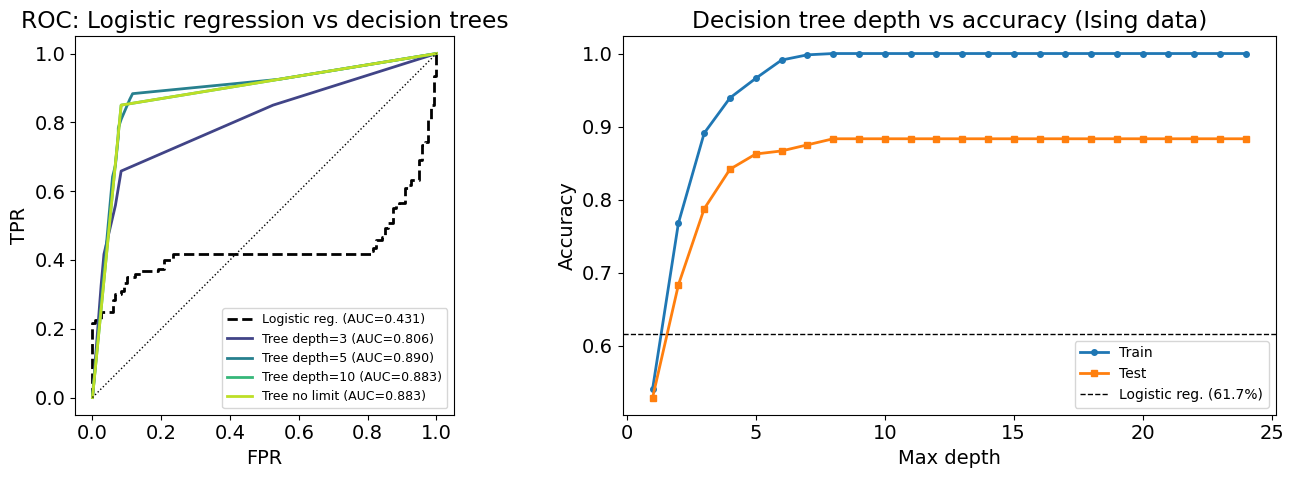

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
axes[0].plot(fpr_lr, tpr_lr, 'k--', lw=2, label=f'Logistic reg. (AUC={auc_lr:.3f})')
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(depths_ising)))
for (d, r), c in zip(tree_results.items(), colors):
    label = f'depth={d}' if d is not None else 'no limit'
    axes[0].plot(r['fpr'], r['tpr'], lw=2, color=c, label=f'Tree {label} (AUC={r["auc"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k:', lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC: Logistic regression vs decision trees')
axes[0].legend(fontsize=9); axes[0].set_aspect('equal')

# Accuracy vs depth for Ising
d_range = list(range(1, 25))
tr_ising, te_ising = [], []
for d in d_range:
    t = DecisionTreeClassifier(max_depth=d, random_state=0)
    t.fit(X_tr_is, y_tr_is)
    tr_ising.append(t.score(X_tr_is, y_tr_is))
    te_ising.append(t.score(X_te_is, y_te_is))

axes[1].plot(d_range, tr_ising, 'o-', lw=2, markersize=4, label='Train')
axes[1].plot(d_range, te_ising, 's-', lw=2, markersize=4, label='Test')
axes[1].axhline(acc_lr, color='k', ls='--', lw=1, label=f'Logistic reg. ({acc_lr:.1%})')
axes[1].set_xlabel('Max depth')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Decision tree depth vs accuracy (Ising data)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

### What we see

The decision tree outperforms logistic regression on the Ising data — even a relatively shallow tree — because it can handle the non-linearity. The tree can effectively learn rules like: "if the sum of spins in some region is very positive OR very negative, classify as ordered." These axis-aligned splits can approximate the absolute-value operation that logistic regression cannot.

However, the unlimited tree overfits: training accuracy reaches 100% while test accuracy degrades.

### Looking inside the tree: what did it learn?

Let us look at the top of a moderate-depth tree to see what features it considers most important.

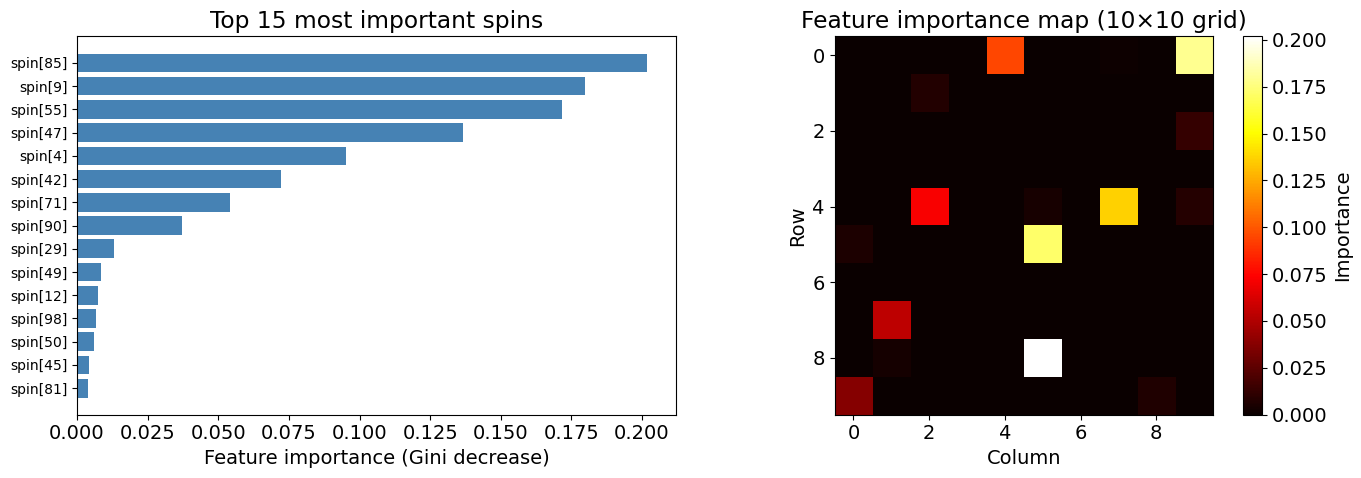

The tree uses many individual spins — it has no concept of the global magnetization.
This is a key limitation: each split looks at ONE feature at a time.
Compare to the neural network, which computes global functions of all inputs simultaneously.


In [11]:
# Feature importances from a depth-5 tree
tree_d5 = tree_results[5]['model']
importances = tree_d5.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of top features
top_k = 15
top_idx = np.argsort(importances)[::-1][:top_k]
axes[0].barh(range(top_k), importances[top_idx], color='steelblue')
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels([f'spin[{i}]' for i in top_idx], fontsize=10)
axes[0].set_xlabel('Feature importance (Gini decrease)')
axes[0].set_title('Top 15 most important spins')
axes[0].invert_yaxis()

# Show importances as a 10x10 heatmap
axes[1].imshow(importances.reshape(10, 10), cmap='hot')
axes[1].set_title('Feature importance map (10×10 grid)')
axes[1].set_xlabel('Column'); axes[1].set_ylabel('Row')
plt.colorbar(axes[1].images[0], ax=axes[1], label='Importance')

plt.tight_layout()
plt.show()

print('The tree uses many individual spins — it has no concept of the global magnetization.')
print('This is a key limitation: each split looks at ONE feature at a time.')
print('Compare to the neural network, which computes global functions of all inputs simultaneously.')

### Trees vs neural networks: a key difference

The tree works by splitting on individual spins, one at a time. It can approximate non-linear boundaries, but it does so **locally** — each split considers only one feature. To approximate a global quantity like $|M| = |\sum_i s_i| / N$, the tree needs many splits, each carving out a small region of the 100-dimensional feature space.

A neural network computes $\mathbf{w}^T \mathbf{x}$ in a single operation — it considers all features simultaneously and can learn global quantities directly.

This explains why:
- Trees need more depth (complexity) to match a neural network on this problem
- Trees are more prone to overfitting here — they need many parameters to represent what the NN captures in a few
- But trees are **much** more interpretable: you can read every decision

Tomorrow we will see how **ensembles** of trees can overcome these limitations.

---
## Summary

| | Logistic regression | Decision tree | Neural network |
|---|---|---|---|
| **Boundary type** | Hyperplane (linear) | Axis-aligned rectangles | Arbitrary smooth curves |
| **Non-linearity** | None (without feature engineering) | Built-in via recursive splits | Built-in via activations |
| **Interpretability** | Weights are readable | Entire logic is readable | Opaque |
| **Overfitting control** | Regularization ($\lambda$) | max_depth, min_samples | Early stopping, dropout |
| **Failure mode** | Cannot learn non-linear boundaries | Memorizes with too much depth | Memorizes with too many parameters |

### Recurring themes

- **Bias-variance tradeoff** (Module 1 → 4 → 5 → 6): tree depth controls complexity just like polynomial degree, $k$ in KNN, or network size
- **Train/test split** (Module 4 → 5 → 6): essential for detecting overfitting in every model we encounter
- **The right representation matters** (Module 3 → 5 → 6): the tree struggles with global features because it splits one feature at a time

### Looking ahead

Single trees are interpretable but fragile. The breakthrough insight of ensemble methods is: **if you average many fragile models, the result can be remarkably robust**. This is the topic of Day 2.

---
## Remaining class time: work on HW 6

